#### 𝗚𝗥𝗢𝗨𝗣 𝟱 - 𝗕𝗦𝗜𝗧-𝟮𝗔

Members: 
1. Domingo, Mario Jr. C.
2. Daclison, Trisha Jamaica U.
3. Dela Cruz, Bic Julian

#### **1. Background of the Study**

**Title:** Forecasting Population Growth Trends in the Philippines (2020–2025)

**Source:** Philippines Population Projection Dataset (2020–2025), Admin3 / PSA (psa.gov.ph)

---

**Brief Description of Dataset**
- **Size:** 1,635 rows × 12 columns  
- **Unit of analysis:** One row = one city/municipality  
- **Time coverage:** July 2020 to July 2025 (midyear population, levels)

**Main Columns**
- `Region` — Administrative region name  
- `Region_pcode` — Region code  
- `Province` — Province name  
- `Province_pcode` — Province code  
- `Municipality_City` — City/Municipality name  
- `Mun_pcode` — City/Municipality code  
- `July2020` … `July2025` — Projected midyear population (levels)

> The dataset provides municipal/city population projections based on the 2015 Census and PSA growth-rate estimates.

---

**Selected Features (Input Variables for Clustering)**

- `July2020` … `July2025` — projected midyear population levels for each city/municipality  
- `Total_Growth_2020_2025` — absolute population change between July 2020 and July 2025  
- `Growth_Rate_2020_2025` — percentage population change from July 2020 to July 2025  
- `Avg_Annual_Growth_2020_2025` — average yearly population growth rate over the 5-year period  

These features describe both the **level** of population and its **change over time**, which are used by the clustering algorithm to measure similarity between cities and municipalities.

**Clustering Output (Unsupervised “Target”)**

- `Cluster` — data-driven group membership that indicates which population-growth pattern a city or municipality belongs to.  
  The clusters are **not pre-defined labels**; they are discovered automatically by the unsupervised learning algorithm based on similarities across the selected features.

---

**Objectives:** Identify and interpret population growth patterns from 2020 to 2025 for Philippine cities and municipalities using unsupervised learning (clustering).

1. **Identify natural clusters** of cities and municipalities based on projected population levels (2020–2025) and derived growth indicators (total growth, growth rate, and average annual growth).  
2. **Describe and compare the characteristics** of each cluster in terms of population size, growth behaviour, and geographic distribution (region and province).  
3. **Highlight areas with distinct growth profiles** (for example, fast-growing, moderately growing, and slow-growing or stagnant clusters) to provide insights that may support planning and policy discussions.

#### **2. Data Collection/Loading**

In [56]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel sheet into a DataFrame
df = pd.read_excel("Philippines Population Projection dataset (2020–2025).xlsx")

# Display the first 10 rows
df.head(10)


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702
5,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Burgos,PH012806000,9948,9970,9987,10000,10009,10013
6,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Carasi,PH012807000,1644,1658,1672,1684,1696,1708
7,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Currimao,PH012808000,12419,12451,12477,12498,12513,12523
8,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dingras,PH012809000,39673,39850,40009,40152,40277,40386
9,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dumalneg,PH012810000,3267,3332,3397,3461,3525,3589


In [57]:
# Safety: reset pandas float display format (prevents 'all 0/1' confusion)
import pandas as pd
try:
    pd.reset_option('display.float_format')
except Exception:
    pass

#### **3. Data Information and Summary Statistics**


In [58]:
# Check the Structure of the Data (Columns, Data Types and Non-Null Counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Region             1634 non-null   object
 1   Region_pcode       1634 non-null   object
 2   Province           1634 non-null   object
 3   Province_pcode     1634 non-null   object
 4   Municipality_City  1634 non-null   object
 5   Mun_Pcode          1634 non-null   object
 6   July2020           1634 non-null   int64 
 7   July2021           1634 non-null   int64 
 8   July2022           1634 non-null   int64 
 9   July2023           1634 non-null   int64 
 10  July2024           1634 non-null   int64 
 11  July2025           1634 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 153.3+ KB


In [59]:
# Check for Missing or Invalid Values
df.isnull().sum()
df.isnull().sum()

Region               0
Region_pcode         0
Province             0
Province_pcode       0
Municipality_City    0
Mun_Pcode            0
July2020             0
July2021             0
July2022             0
July2023             0
July2024             0
July2025             0
dtype: int64

In [60]:
# Get Summary Statistics for Numeric Columns
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025
count,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03
mean,6.656791e+04,6.744102e+04,6.828167e+04,6.908982e+04,6.986763e+04,7.061077e+04
std,1.401156e+05,1.419562e+05,1.437248e+05,1.454233e+05,1.470567e+05,1.486184e+05
min,1.930000e+02,1.940000e+02,1.950000e+02,1.960000e+02,1.960000e+02,1.960000e+02
25%,2.275775e+04,2.286050e+04,2.309700e+04,2.324975e+04,2.332225e+04,2.352050e+04
50%,3.625500e+04,3.671850e+04,3.696050e+04,3.739400e+04,3.770550e+04,3.800550e+04
75%,6.501125e+04,6.549650e+04,6.608950e+04,6.653050e+04,6.704175e+04,6.764600e+04
max,3.080813e+06,3.102433e+06,3.121477e+06,3.137962e+06,3.151858e+06,3.163105e+06


In [61]:
# Import display function to show DataFrames neatly (Formatted Output)
from IPython.display import display

# Reshape data into long format for easier analysis
df_melted = df.melt (
    id_vars = ['Region', 'Region_pcode', 'Province', 'Province_pcode', 'Municipality_City', 'Mun_Pcode'],
    var_name = 'Year',
    value_name = 'Population'
)

# Display the first few rows of the reshaped data
display(df_melted.head())

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,Year,Population
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,July2020,1823
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,July2020,32778
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,July2020,32218
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,July2020,14954
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,July2020,56248


##### Summary & Observation:

- The dataset contains 1,634 rows and 12 columns evenly divided between (6) categorical and (6) numerical data types
- There are no missing values in any columns
- Population columns (July2020 - July2025) are integers while regional identifies are objects (strings)
- Data types are correct and appropriate for analysis
- The population values range from 193 to over 3 million with varying sizes of local government units
  - Summary statistics reveal that population gradually increases from 2020 to 2025, indicating consistent year-over-year growth
  - Average population per city or municipality ranges from 66,568 in 2020 to 70,611 in 2025
- The standard deviation is high due to population differences between small municipalities and large cities
- No outliers or invalid entries were found in the dataset
- Reshaping data using `df.melt()` successfully transformed dataset into long format for easier analysis and visualization of trends over time


#### **4. Data Cleaning**

In [62]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [63]:
# Verify no negative and unrealistic population values
(df[['July2020', 'July2021', 'July2022', 'July2023', 'July2024', 'July2025']] < 0).sum()

July2020    0
July2021    0
July2022    0
July2023    0
July2024    0
July2025    0
dtype: int64

In [64]:
# Clean text data by removing leading/trailing spaces
df['Region'] = df['Region'].str.strip()
df['Province'] = df['Province'].str.strip()
df['Municipality_City'] = df['Municipality_City'].str.strip()

# Display first 10 rows confirm text fields look clean and consistent
display(df[['Region', 'Province', 'Municipality_City']].head(10))

# Check if there are still rows with leading/trailing spaces after cleaning
df[
    (df['Region'] != df['Region'].str.strip()) |
    (df['Province'] != df['Province'].str.strip()) |
    (df['Municipality_City'] != df['Municipality_City'].str.strip())
]

# Output will be an empty table meaning all spaces were successfully removed

,Region,Province,Municipality_City
0,Region I (Ilocos Region),Ilocos Norte,Adams
1,Region I (Ilocos Region),Ilocos Norte,Bacarra
2,Region I (Ilocos Region),Ilocos Norte,Badoc
3,Region I (Ilocos Region),Ilocos Norte,Bangui
4,Region I (Ilocos Region),Ilocos Norte,City of Batac
5,Region I (Ilocos Region),Ilocos Norte,Burgos
6,Region I (Ilocos Region),Ilocos Norte,Carasi
7,Region I (Ilocos Region),Ilocos Norte,Currimao
8,Region I (Ilocos Region),Ilocos Norte,Dingras
9,Region I (Ilocos Region),Ilocos Norte,Dumalneg


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025


In [65]:
# Recheck and Drop Duplicates (For Safety)
df.drop_duplicates(inplace=True)

df.head()

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702


##### Summary & Observation:

1. **Check for Duplicate Rows**
   - 0 means there are no duplicate entries, the dataset is unique and clean (population counts and locality)

2. **Verify for Negative or Unrealistic Population Values**
   - All values were 0, confirms that every record has valid population data
   - All columns for population years (July 2020 - 2025) contain no negative or unrealistic values

3. **Remove Leading/Trailing Spaces from Text Columns**
   - Empty table result after rechecking means all spaces were successfully cleaned
   - Confirms text fields look consistent and formatted properly

4. **Recheck and Drop Duplicates (For Safety)**
   - No duplicates found, ensuring that if any exist in future updates they will be removed automatically
   - Dataset remains 1,634 unique records after cleaning


#### **5. Data Engineering / Pre-Processing**

In [66]:
# 5. Data Engineering / Pre-processing

from sklearn.preprocessing import StandardScaler

# 5.1 Add growth-related features

# Total growth from 2020 to 2025
df["Total_Growth_2020_2025"] = df["July2025"] - df["July2020"]

# Growth rate (%) from 2020 to 2025
df["Growth_Rate_2020_2025"] = (
    (df["July2025"] - df["July2020"]) / df["July2020"]
) * 100

# Average annual growth (2020–2025)
years_between = 5
df["Avg_Annual_Growth_2020_2025"] = (df["July2025"] / df["July2020"])**(1 / years_between) - 1

# 5.2 Select numeric features for modeling

numeric_features = [
    "July2020", "July2021", "July2022",
    "July2023", "July2024", "July2025",
    "Total_Growth_2020_2025",
    "Growth_Rate_2020_2025",
    "Avg_Annual_Growth_2020_2025"
]

X = df[numeric_features]

# 5.3 Scale the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame version for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features, index=df.index)

X_scaled_df.head()


,July2020,July2021,July2022,July2023,July2024,July2025,Total_Growth_2020_2025,Growth_Rate_2020_2025,Avg_Annual_Growth_2020_2025
0,-0.462223,-0.462355,-0.462495,-0.462631,-0.462777,-0.462909,-0.341874,-0.822725,-0.869698
1,-0.241231,-0.243748,-0.246196,-0.248584,-0.250923,-0.253187,-0.324572,-0.822593,-0.869553
2,-0.245229,-0.247631,-0.249975,-0.252250,-0.254481,-0.256647,-0.320671,-0.794439,-0.838580
3,-0.368479,-0.369579,-0.370667,-0.371724,-0.372764,-0.373768,-0.332290,-0.790298,-0.834027
4,-0.073675,-0.077879,-0.081971,-0.085947,-0.089834,-0.093616,-0.304386,-0.795547,-0.839798


**Summary**

**What you see:**

1. **`Total_Growth_2020_2025`**  
   - **Formula:** `July2025 − July2020`  
   - **Meaning:** How many people were added between 2020 and 2025.  
   - A large positive value means the city or municipality grew a lot in total.

2. **`Growth_Rate_2020_2025`**  
   - **Formula:** `(July2025 − July2020) / July2020 * 100`  
   - **Meaning:** How fast the population grew in percent over the period.  
   - Example: A value of 20 percent means the 2025 population is about 1.2 times the 2020 population.

3. **`Avg_Annual_Growth_2020_2025`**  
   - **Formula:** `(July2025 / July2020)**(1/5) − 1`  
   - **Meaning:** Average growth per year across the 5 years (similar to a yearly interest rate).

4. A preview of `X_scaled_df.head()` where all columns (`July2020`–`July2025` and the three growth features) have values roughly between −1 and +1.

5. Output of `X_scaled_df.mean()` showing that each feature has a mean extremely close to 0, and `X_scaled_df.std()` showing that each feature has a standard deviation close to 1.

---

**What the results mean:**

- The three new columns successfully capture **change over time** (total growth, growth rate, and average annual growth) instead of only current population size.  
- Standardization using `StandardScaler` has put all features on a **common scale** (mean 0, standard deviation 1).  
- Cities below the overall average for a feature have negative standardized values; those above average have positive values.  
- Because everything is standardized, no single feature with large raw values (such as July 2025 population) will dominate the distance calculations during clustering.

---

**Conclusion:**

- The dataset is now **feature-engineered and scaled appropriately** for unsupervised learning.  
- The model will be able to group cities and municipalities based not only on how large they are, but also on **how their populations have changed from 2020 to 2025**, and it will do so in a way that treats all selected features fairly.
- Population levels and growth patterns are now represented in a standardized way, so clustering methods like k-means can focus on genuine similarities and differences between cities or municipalities rather than being driven by raw scale.


#### **6. Data Visualization**

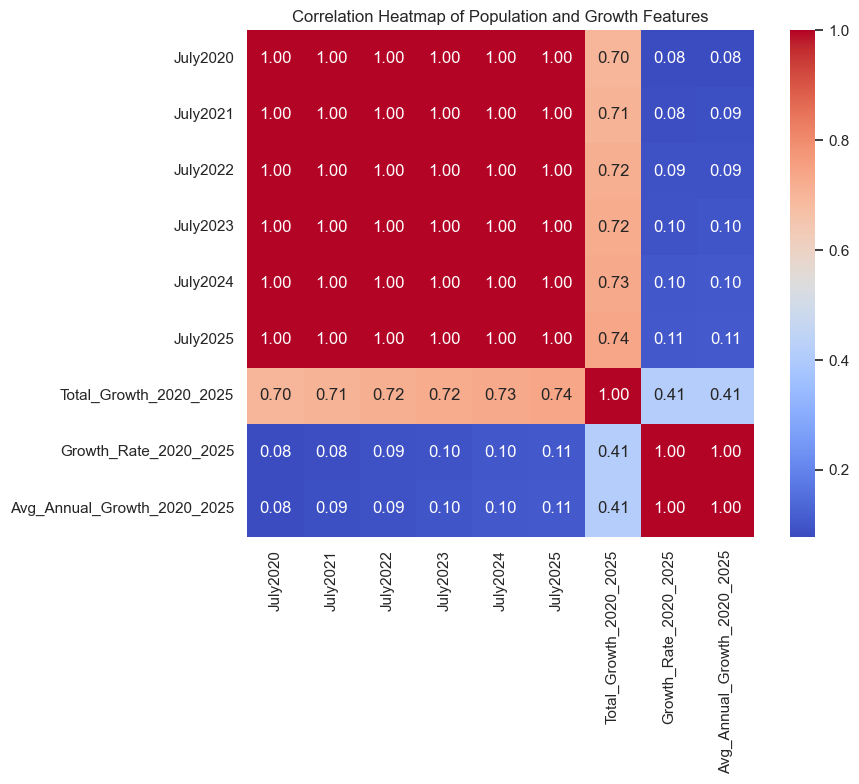

In [67]:
# 6. Data Visualization

# Goal: use charts to explore population levels and growth patterns before applying unsupervised learning (clustering).

# Import visualization libraries and set style

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# 6.1 Correlation heatmap for numeric features

plt.figure(figsize=(10, 8))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Population and Growth Features")
plt.tight_layout()
plt.show()


**6.1 Correlation Heatmap of Population and Growth Features**

**Summary**

**What you see:**

- The six population columns (`July2020`–`July2025`) all have correlation values very close to **1.00** with each other.  
- `Total_Growth_2020_2025` has a **moderate positive correlation** (~0.70–0.74) with the population level columns.  
- `Growth_Rate_2020_2025` and `Avg_Annual_Growth_2020_2025` are **perfectly correlated** with each other (1.00) and have only **weak correlations** (~0.08–0.11) with the population level columns.  
- `Growth_Rate_2020_2025` and `Avg_Annual_Growth_2020_2025` show a **moderate correlation** (~0.41) with `Total_Growth_2020_2025`.

**Interpretation**

- The yearly population columns are almost identical in behavior: cities that are large in 2020 remain large in the later years, and small municipalities remain small. This means the population-level features are **highly redundant**.  
- `Total_Growth_2020_2025` is related to population size (bigger cities tend to add more people in absolute numbers), but it also reflects **overall change in population** over the five-year period.  
- The growth-rate features (`Growth_Rate_2020_2025` and `Avg_Annual_Growth_2020_2025`) capture a **different aspect** of the data: how fast each city or municipality grows relative to its starting population. Their low correlation with the population levels shows that places with similar size can still have very different growth rates.

**Conclusion**

- The dataset now contains two main types of information:  
  1. **Population level** (size of each city/municipality), which is strongly consistent across years.  
  2. **Growth behavior** (absolute and relative growth), which adds new variation and is less tied to size.  

- This structure is suitable for unsupervised learning, because clustering algorithms can use both size and growth behavior to discover **distinct population-growth patterns** among Philippine cities and municipalities.


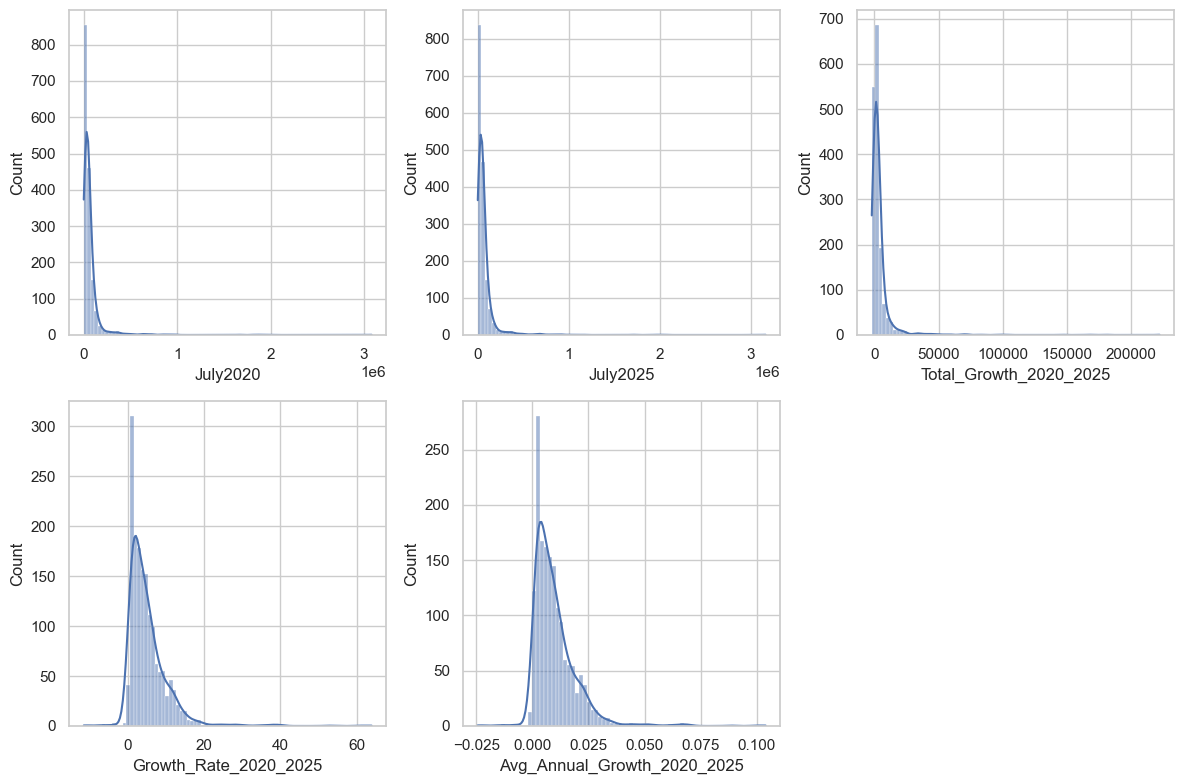

In [68]:
# 6.2 Histograms for selected features

features_to_plot = [
    "July2020",
    "July2025",
    "Total_Growth_2020_2025",
    "Growth_Rate_2020_2025",
    "Avg_Annual_Growth_2020_2025"
]

plt.figure(figsize=(12, 8))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


**6.2 Histograms of Population and Growth Features**

**Summary**

**What you see:**

- **July2020 and July2025:**  
  - Both distributions are **strongly right-skewed**.  
  - Most cities/municipalities have relatively **small populations**, while a few have very large populations (long tail extending to the right).

- **Total_Growth_2020_2025:**  
  - Also right-skewed, with many areas showing **modest absolute growth** and a smaller number experiencing **very large increases** in population.

- **Growth_Rate_2020_2025:**  
  - Most observations are concentrated at **low to moderate growth rates** (roughly in the lower single digits), with a right tail indicating a few municipalities with unusually high percentage growth.

- **Avg_Annual_Growth_2020_2025:**  
  - The distribution is fairly tight, centered around **small positive yearly growth rates**, with some negative values (slight declines) and a few higher-growth outliers.

**Interpretation**

- The population variables confirm that the Philippines has **many small municipalities and only a few very large cities**, which explains the long right tails in July2020 and July2025.  
- The growth-related variables show that **most areas grow slowly and steadily**, while a minority experience **rapid or exceptional growth**, either in total numbers or in percentage terms.  
- These skewed distributions suggest that clustering may separate:  
  - small vs large population centers, and  
  - typical vs high-growth (or declining) municipalities.

**Conclusion**

- The histograms support the idea that there are **distinct groups** of cities/municipalities in terms of both **size** and **growth behavior**.  
- This justifies the use of unsupervised learning (clustering) to uncover meaningful population-growth patterns across Philippine localities.


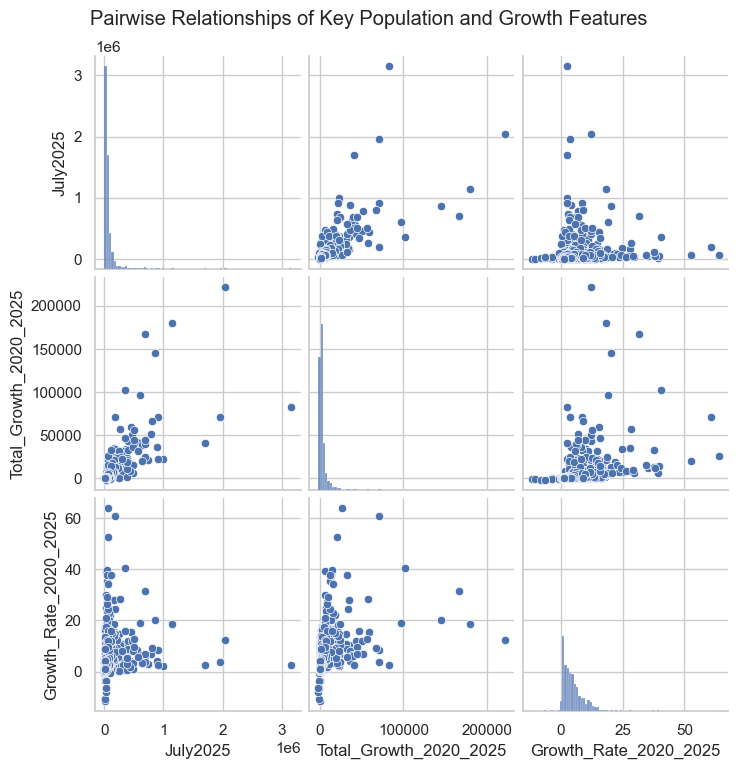

In [69]:
# 6.3 Pairwise relationships between key variables

pair_features = [
    "July2025",
    "Total_Growth_2020_2025",
    "Growth_Rate_2020_2025"
]

sns.pairplot(df[pair_features])
plt.suptitle("Pairwise Relationships of Key Population and Growth Features", y=1.02)
plt.show()


**6.3 Pairwise Relationships of Key Population and Growth Features**

**Summary**

**What you see:**

- The pairplot shows scatter plots and histograms for three variables:  
  `July2025`, `Total_Growth_2020_2025`, and `Growth_Rate_2020_2025`.
- On the diagonal, the histograms confirm the earlier findings: all three variables are **right-skewed**, with many municipalities in the lower ranges and a few extreme values.
- The scatter plot of **July2025 vs. Total_Growth_2020_2025** shows an upward cloud:  
  larger cities tend to have **larger absolute population increases**.
- The scatter plot of **July2025 vs. Growth_Rate_2020_2025** shows a wide vertical band:  
  growth rates vary a lot even among cities with similar population sizes.
- The scatter plot of **Total_Growth_2020_2025 vs. Growth_Rate_2020_2025** also forms a broad cloud:  
  municipalities with high total growth do not always have the highest percentage growth, and vice versa.

**Interpretation**

- Population **size** (July2025) and **total growth** are clearly related: big cities add more people in absolute terms, but there is still visible spread, indicating some large cities grow more strongly than others.
- **Growth rate** behaves somewhat independently of size: both small and large municipalities can show low, moderate, or high percentage growth.
- The combination of these relationships suggests that municipalities can differ along **two dimensions**:
  1. How **large** they are (current population).
  2. How **intensely** they are growing (absolute and percentage growth).

**Conclusion**

- These pairwise patterns support the use of clustering: the algorithm can discover groups such as  
  “large–high growth,” “large–moderate growth,” “small–high growth,” and “small–low growth” municipalities.  
- Such clusters will help characterize distinct **population-growth profiles** across Philippine cities and municipalities.


#### **7. Data Splitting (Training and Testing Set)**

In [70]:
# 7. Data Splitting (Training and Testing Set)

# In supervised learning, the dataset is usually split into training and testing sets for both features `X` and target `y`.  
# In this unsupervised learning setup (clustering), there is *no target label*; we only have the feature matrix with population and growth variables.

# - `X_train` — 80% of cities/municipalities, used to **fit** the clustering model.
# - `X_test` — 20% of cities/municipalities, used later to **check the stability and general behaviour** of the learned clusters.

# This split helps ensure that the clustering structure is not driven only by a small subset of the data and provides a way to examine how well the learned clusters generalize to unseen municipalities.

from sklearn.model_selection import train_test_split

# Use the standardized feature matrix for splitting
# X_scaled_df was created in Section 5 (scaled version of numeric_features)

X_train, X_test = train_test_split(
    X_scaled_df,
    test_size=0.2,      # 20% for testing
    random_state=42,    # fixed seed for reproducibility
    shuffle=True
)

# Keep the corresponding original rows for later interpretation
df_train = df.loc[X_train.index]
df_test = df.loc[X_test.index]

print("Training set shape (X_train):", X_train.shape)
print("Testing set shape  (X_test): ", X_test.shape)

Training set shape (X_train): (1307, 9)
Testing set shape  (X_test):  (327, 9)


**Summary**

**What you see:**

- Printed output:  
  - `Training set shape (X_train): (1307, 9)`  
  - `Testing set shape  (X_test):  (327, 9)`
- This means:
  - `X_train` contains **1,307 rows** (cities/municipalities) and **9 features** (population and growth variables).  
  - `X_test` contains **327 rows** and the same **9 features**.

**Interpretation**

- The dataset was split into:
  - **80% training data** (1,307 municipalities) to fit the clustering model.  
  - **20% testing data** (327 municipalities) to later check how well the learned clusters generalize to new, unseen observations.
- Because this is **unsupervised learning**, there is **no target label `y`**.  
  The split is applied only to the standardized feature matrix (`X_scaled_df`).

**Conclusion**

- The data splitting step confirms that the feature matrix has been divided into training and testing portions in a reproducible way (`random_state=42`).  
- This prepares the dataset for the next step, where the clustering algorithm will be trained on `X_train` and its stability or behavior can be examined using `X_test`.


#### **8. Model Selection and Training**

In [71]:
# 8. Model Selection and Training

# Import needed libraries
# - KMeans: the clustering algorithm we use
# - display: to show nice tables in Jupyter
# - pandas: for DataFrame manipulations
from sklearn.cluster import KMeans
from IPython.display import display
import pandas as pd


# 8.1 Fit the K-Means model

# Choose the number of clusters (here we decided k = 5)
k = 5

# Create the KMeans model with:
# - n_clusters = k      → how many groups we want
# - random_state = 42   → makes results reproducible
# - n_init = 10         → run K-Means several times and keep the best solution
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Fit the model on the training data (X_train is the scaled features)
kmeans.fit(X_train)

# Assign a cluster label to each row in the training and testing sets
df_train["Cluster"] = kmeans.predict(X_train)
df_test["Cluster"]  = kmeans.predict(X_test)


# 8.2 Cluster counts

# Count how many municipalities fall into each cluster (0, 1, 2, 3, 4)
print("⸻ Cluster counts in training data ⸻")
cluster_counts = df_train["Cluster"].value_counts().sort_index()

# Turn counts into a small table with a clear index name
counts_df = cluster_counts.to_frame(name="Count")
counts_df.index.name = "Cluster"
display(counts_df)


# 8.3 Cluster summary (counts + percent)

# Compute the percentage of the dataset in each cluster
cluster_percent = (cluster_counts / len(df_train) * 100).round(2)

# Combine counts and percentages into one summary table
cluster_summary = pd.DataFrame({
    "Count": cluster_counts,
    "Percent": cluster_percent
})
cluster_summary.index.name = "Cluster"

print("\n⸻ Cluster summary (training data) ⸻")
display(cluster_summary)


# 8.4 Average profile of each cluster 

# Pick the key features that describe population and growth
key_features = [
    "July2025",
    "Total_Growth_2020_2025",
    "Growth_Rate_2020_2025",
    "Avg_Annual_Growth_2020_2025"
]

# For each cluster, compute the mean of these features.
# This gives a "typical" profile for that cluster.
cluster_profile = (
    df_train
    .groupby("Cluster")[key_features]
    .mean()
    .round(2)
)
cluster_profile.index.name = "Cluster"

print("\n⸻ Average profile of each cluster (training data) ⸻")

# Show the profile table with numbers formatted nicely
display(cluster_profile.style.format("{:,.2f}"))


⸻ Cluster counts in training data ⸻


,Count
Cluster,
0,989
1,4
2,20
3,65
4,229



⸻ Cluster summary (training data) ⸻


,Count,Percent
Cluster,,
0,989,75.67
1,4,0.31
2,20,1.53
3,65,4.97
4,229,17.52



⸻ Average profile of each cluster (training data) ⸻


,July2025,Total_Growth_2020_2025,Growth_Rate_2020_2025,Avg_Annual_Growth_2020_2025
Cluster,,,,
0,"42,921.55","1,418.23",3.17,0.01
1,"2,217,760.75","104,057.25",5.26,0.01
2,"724,266.00","63,947.90",11.10,0.02
3,"256,747.88","13,045.46",5.74,0.01
4,"54,094.53","6,337.83",13.17,0.02


### **Summary:**

**Chosen Model: K-Means Clustering**

For this study, we use **K-Means clustering** as the main unsupervised learning model.

**Why K-Means is appropriate for this problem:**

- The goal is to **group cities and municipalities with similar population and growth patterns** from 2020–2025.  
- All input variables are **numeric and standardized** (`July2020`–`July2025`, `Total_Growth_2020_2025`, `Growth_Rate_2020_2025`, `Avg_Annual_Growth_2020_2025`), which fits well with K-Means, which uses **Euclidean distance**.
- The dataset has around **1,600 observations and 9 features**, which is a good size for K-Means:  
  it is **computationally efficient** and scales well to this number of records.
- K-Means provides **interpretable results**: each cluster is summarized by a **centroid** representing a typical population-growth profile (e.g., “small–slow growth” or “large–fast growth” municipalities).
- Other unsupervised methods:
  - **Hierarchical clustering** is more expensive on larger datasets and harder to apply to 1,600+ units.
  - **PCA** is mainly for **dimensionality reduction/visualization**, not for forming groups by itself.
  
Given these points, K-Means is a suitable and practical choice for discovering **natural clusters of population-growth profiles** among Philippine cities and municipalities.

---

**Summary of K-Means Clustering Results (k = 5)**

**What you see:**

- The algorithm grouped the municipalities into **5 clusters**.
- **Cluster sizes:**
  - Cluster 0 → 989 LGUs (75.67%)
  - Cluster 1 → 4 LGUs (0.31%)
  - Cluster 2 → 20 LGUs (1.53%)
  - Cluster 3 → 65 LGUs (4.97%)
  - Cluster 4 → 229 LGUs (17.52%)
- The table of averages shows the **typical July 2025 population and growth** for each cluster.

---

**Interpretation of each cluster:**

1. **Cluster 0 – Small/medium, low growth (majority)**  
   - Avg July 2025 population ≈ **42,922**  
   - Total growth ≈ **1,418** people  
   - Growth rate ≈ **3.17%** (around 0.6% per year)  
   → This is the **typical municipality**: relatively small and growing slowly but steadily.

   **Example LGUs from the data:**
   - Cainta, Rizal  
   - City of Navotas, NCR Third District  
   - City of Meycauayan, Bulacan  
   - City of Valencia, Bukidnon  
   - Calbayog City, Samar (Western Samar)  

   **You can describe these as typical small to mid-sized municipalities/cities with slow, steady growth.**

---

2. **Cluster 1 – Mega-cities**  
   - Avg July 2025 population ≈ **2,217,761**  
   - Total growth ≈ **104,057** people  
   - Growth rate ≈ **5.26%**  
   → Only **4 LGUs**, but extremely large. These are the **biggest cities in the country**, behaving very differently from the rest.

    **LGUs in this cluster:**
   - City of Manila, NCR First District  
   - Davao City, Davao del Sur  
   - Quezon City, NCR Second District  
   - Caloocan City, NCR Third District  

   **These are your mega-cities – clearly much larger than all other LGUs.**

---

3. **Cluster 2 – Very large, fast-growing cities**  
   - Avg July 2025 population ≈ **724,266**  
   - Total growth ≈ **63,948** people  
   - Growth rate ≈ **11.10%** (about 2%+ per year)  
   → Large urban centers with **strong population expansion**, both in level and in percentage.

   **Example LGUs from the data:**
   - Taguig City, NCR Fourth District  
   - Cebu City (Capital), Cebu  
   - Zamboanga City, Zamboanga del Sur  
   - City of Pasig, NCR Second District  
   - City of Antipolo, Rizal  

   These are **major urban areas that continue to grow quickly**, both in total population and in growth rate.

---

4. **Cluster 3 – Medium/large, moderate growth**  
   - Avg July 2025 population ≈ **256,748**  
   - Total growth ≈ **13,045** people  
   - Growth rate ≈ **5.74%**  
   → Mid-sized cities with **moderate growth**, between the slow majority and the fast-growing clusters.

    **Example LGUs from the data:**
   - Taytay, Rizal  
   - City of San Fernando (Capital), Pampanga  
   - Mabalacat City, Pampanga  
   - Cotabato City (Not a Province)  
   - Santa Maria, Bulacan  
   - Puerto Princesa City (Capital), Palawan  

   These represent **medium to large urban centers** that are growing at a steady but not extreme pace.


---   

5. **Cluster 4 – Small/medium, very high percentage growth**  
   - Avg July 2025 population ≈ **54,095**  
   - Total growth ≈ **6,338** people  
   - Growth rate ≈ **13.17%** (around 2–3% per year)  
   → Mostly smaller LGUs that are **growing very quickly in percentage terms**, even if their absolute population size is not very large.

   **Example LGUs from the data:**
   - Santo Tomas, Batangas  
   - Pikit, Cotabato (North Cotabato)  
   - Naic, Cavite  
   - Carmona, Cavite  
   - Castillejos, Zambales  

   These are **emerging growth areas**: small to mid-sized municipalities with very rapid population increases.

---

**Overall conclusion:**

- The model identifies **five distinct population–growth profiles**:
  - a large group of **small, slow-growing** municipalities,
  - a group of **small but very fast-growing** areas,
  - **medium and large cities** with moderate growth,
  - **large, high-growth** urban centers,
  - and a tiny set of **mega-cities** that are outliers in size.
- These clusters can be used in the study to describe and compare **different types of population growth patterns** across Philippine cities and municipalities.


#### **9. Prediction Values**

In [72]:
# 1. Generate the prediction values (Cluster Labels)
y_pred_test = kmeans.predict(X_test)

# 2. Assign the predictions to the original test DataFrame
df_test["Cluster"] = y_pred_test

# 3. Combine the training results (already in df_train) and test results
#    This creates the final dataset (df_final) with cluster assignments for all 1,635 municipalities.
df_final = pd.concat([df_train, df_test]).sort_index()

# 4. Display the first few results
print("First 10 Predicted Clusters on Test Data:")
print(df_test[['Municipality_City', 'Cluster']].head(10).to_markdown(index=False))

First 10 Predicted Clusters on Test Data:
| Municipality_City   |   Cluster |
|:--------------------|----------:|
| Sadanga             |         0 |
| Malitbog            |         0 |
| Ocampo              |         0 |
| City of Tabaco      |         3 |
| Dolores             |         4 |
| Sirawai             |         4 |
| Talisay             |         0 |
| Balamban            |         4 |
| Pigkawayan          |         0 |
| Nampicuan           |         4 |


#### **10. Visualization of Model Analysis**

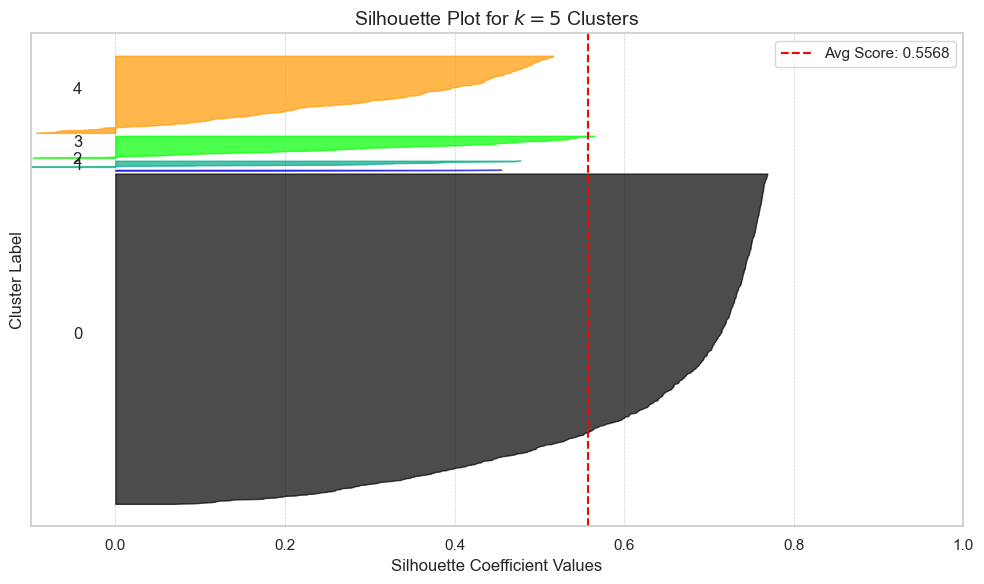

In [73]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# 1. Calculate the overall Average Silhouette Score
cluster_labels = kmeans.predict(X_scaled_df)
silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)

# 2. Generate the Silhouette Plot (Visualizing individual sample scores)
sample_silhouette_values = silhouette_samples(X_scaled_df, cluster_labels)
n_clusters = 5
fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

# Get the colormap object using the modern Matplotlib method
cmap = plt.colormaps['nipy_spectral'] # <-- FIX APPLIED HERE

y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = \
        sample_silhouette_values[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Call the cmap object with the normalized value
    color = cmap(float(i) / n_clusters)

    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

ax1.set_title("Silhouette Plot for $k=5$ Clusters", fontsize=14)
ax1.set_xlabel("Silhouette Coefficient Values", fontsize=12)
ax1.set_ylabel("Cluster Label", fontsize=12)

ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f'Avg Score: {silhouette_avg:.4f}')
ax1.legend()
ax1.set_yticks([])
ax1.set_xlim([-0.1, 1])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

#### **11. Performance Metrics**

#### **12. Conclusion**